## Neural networks and deep learning

Learn about neural nets and build a model for classifying images of clothes

### Fashion Classification

Dataset:

- Full: https://github.com/alexeygrigorev/clothing-dataset
- Small: https://github.com/alexeygrigorev/clothing-dataset-small

Links:

- https://cs231n.github.io

In [1]:
# clone the repo
!git clone https://github.com/alexeygrigorev/clothing-dataset-small.git

fatal: destination path 'clothing-dataset-small' already exists and is not an empty directory.


## TensorFlow and Keras

- Installing TensorFlow
- Loading Images

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import tensorflow as tf
from tensorflow import keras

In [4]:
from tensorflow.keras.utils import load_img

In [5]:
path = "../06_Deep Learning/clothing-dataset-small/train/t-shirt"
name = "5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg"
full_name = f"{path}/{name}"
img = load_img(full_name, target_size=(299, 299))

## Pre-trained convolutional neural networks

- Imagenet dataset: https://www.image-net.org/
- Pre-trained models: https://keras.io/api/applications/

In [6]:
# import the necessary libraries
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [7]:
# use the pretrained model
model = Xception(weights="imagenet", input_shape=(299, 299, 3))


In [8]:
x = np.array([img])

# use the preprocess input function use by the creators to preprocess the img
X = preprocess_input(x)

# predict the class of the image
pred = model.predict(X)

# use decode predictions to see the class of the image
decode_predictions(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


[[('n03595614', 'jersey', np.float32(0.679244)),
  ('n02916936', 'bulletproof_vest', np.float32(0.039600383)),
  ('n04370456', 'sweatshirt', np.float32(0.03529966)),
  ('n03710637', 'maillot', np.float32(0.010884161)),
  ('n04525038', 'velvet', np.float32(0.0018057661))]]

*The actual class of the image is a shirt, but shirt as a class is not seen in image net, so the pretrained model would be adjusted to be an ideal model for our task of classifying the image*

## Convolutional Neural Network

- Types of layers
- Convolutional Layers and filters
- Dense layers

There are more layers. Read here: https://cs231n.github.io/

## Transfer learning

- Reading data with ImageDataGenerator
- Train Xception on smaller images (150 x 150)

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_gen.flow_from_directory(
    './clothing-dataset-small/train',
    target_size=(150,150),
    batch_size=32
)

Found 3068 images belonging to 10 classes.


In [11]:
## check the classes in the train dataset
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [12]:
X, y = next(train_ds)

In [13]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    './clothing-dataset-small/validation',
    target_size=(150,150),
    batch_size=32,
    shuffle=False
)

Found 341 images belonging to 10 classes.


In [14]:
base_model = Xception(weights="imagenet", 
                      include_top=False, 
                      input_shape=(150, 150, 3))

# freeze convolutional layers
base_model.trainable=False

inputs = keras.Input(shape = (150, 150, 3))

base = base_model(inputs, training = False)

vectors = keras.layers.GlobalAveragePooling2D()(base)

outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs, outputs)

In [15]:
learning_rate = 0.01

optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
loss = keras.losses.CategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=['accuracy']
)

In [16]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.6734 - loss: 1.1888 - val_accuracy: 0.7889 - val_loss: 0.8368
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.8139 - loss: 0.6417 - val_accuracy: 0.7801 - val_loss: 0.8753
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.8761 - loss: 0.3592 - val_accuracy: 0.7947 - val_loss: 0.8990
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.9250 - loss: 0.2093 - val_accuracy: 0.7947 - val_loss: 0.8939
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.9404 - loss: 0.1721 - val_accuracy: 0.8094 - val_loss: 0.8466
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.9508 - loss: 0.1324 - val_accuracy: 0.8152 - val_loss: 0.8773
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.9746 - loss: 0.0891 - val_accuracy: 0.8065 - val_loss: 0.9004
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9804 - loss: 0.0643 - val_accuracy: 0.7918 - v

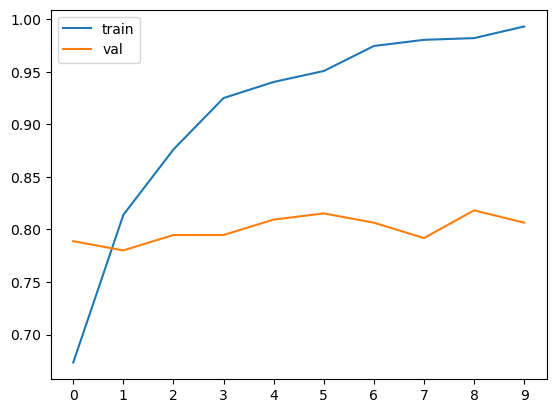

In [17]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xticks(np.arange(10))
plt.legend()
plt.show()

## Adjusting the learning rate

- What's the learning rate
- Trying different values

In [18]:
def make_model(learning_rate):
    base_model = Xception(weights="imagenet", 
                      include_top=False, 
                      input_shape=(150, 150, 3))

    # freeze convolutional layers
    base_model.trainable=False

    ##############################################

    inputs = keras.Input(shape = (150, 150, 3))

    base = base_model(inputs, training = False)

    vectors = keras.layers.GlobalAveragePooling2D()(base)

    outputs = keras.layers.Dense(10)(vectors)

    model = keras.Model(inputs, outputs)

    ##############################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [19]:
scores = {}
for lr in [0.0001, 0.001, 0.01, 0.1]:
    print(lr)

    model = make_model(learning_rate=lr)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history

    print()
    print()

0.0001
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.3537 - loss: 1.9675 - val_accuracy: 0.5279 - val_loss: 1.6105
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.5645 - loss: 1.3971 - val_accuracy: 0.6334 - val_loss: 1.2533
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.6473 - loss: 1.1453 - val_accuracy: 0.6716 - val_loss: 1.0655
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.6894 - loss: 1.0029 - val_accuracy: 0.6979 - val_loss: 0.9573
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.7119 - loss: 0.9090 - val_accuracy: 0.7243 - val_loss: 0.8811
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.7314 - loss: 0.8408 - val_accuracy: 0.7507 - val_loss: 0.8292
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.7454 - loss: 0.7885 - val_accuracy: 0.7537 - val_loss: 0.7868
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.7562 - loss: 0.7458 - val_accuracy: 0.7

*Plot the validation accuracy of the different learning rates*

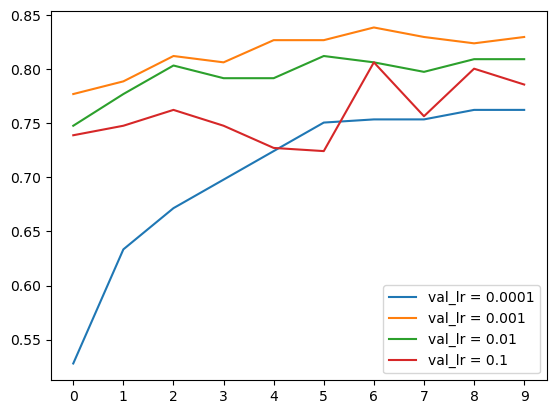

In [20]:
for lr, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=f'val_lr = {lr}')
plt.xticks(np.arange(10))
plt.legend()
plt.show()

*remove the learning rates with the worst performances*

In [21]:
del scores[0.0001]
del scores[0.1]

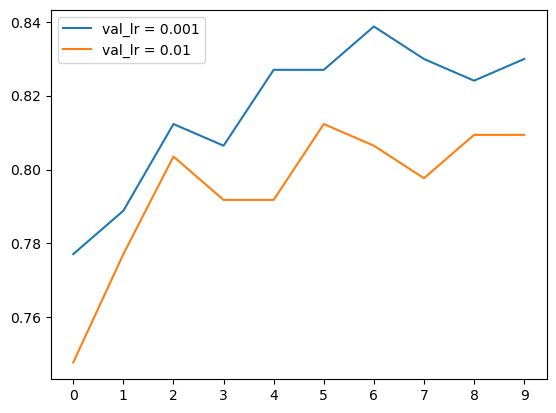

In [22]:
for lr, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=f'val_lr = {lr}')
plt.xticks(np.arange(10))
plt.legend()
plt.show()

*we will go with the learning rate of 0.001 since it is the best learning rate with the best validation scores*

## Checkpointing

- Savings the best model only
- Training a model with callbacks

In [23]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v1_{epoch:02d}_{val_accuracy:.3f}.keras',
    save_best_only=True,
    monitor="val_accuracy",
    mode="max"
)

In [24]:
learning_rate = 0.001
model = make_model(learning_rate=lr)
history = model.fit(
    train_ds, 
    epochs=10, 
    validation_data=val_ds, 
    callbacks=[checkpoint]
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.6659 - loss: 1.2718 - val_accuracy: 0.7566 - val_loss: 0.8672
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.8246 - loss: 0.5464 - val_accuracy: 0.7302 - val_loss: 0.9498
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.8755 - loss: 0.3617 - val_accuracy: 0.7801 - val_loss: 0.9381
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.9068 - loss: 0.2577 - val_accuracy: 0.8094 - val_loss: 0.9164
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.9312 - loss: 0.1932 - val_accuracy: 0.7947 - val_loss: 0.9895
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.9654 - loss: 0.0988 - val_accuracy: 0.8152 - val_loss: 0.8689
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9681 - loss: 0.0881 - val_accuracy: 0.7977 - val_loss: 1.0254
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9762 - loss: 0.0751 - val_accuracy: 0.7859 - v

## Adding more layers

- Adding one inner dense layer
- Experimenting with different sizes of inner layer

In [25]:
def make_model(learning_rate, size_inner=100):
    base_model = Xception(weights="imagenet", 
                      include_top=False, 
                      input_shape=(150, 150, 3))

    # freeze convolutional layers
    base_model.trainable=False

    ##############################################

    inputs = keras.Input(shape = (150, 150, 3))

    base = base_model(inputs, training = False)

    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)

    outputs = keras.layers.Dense(10)(inner)

    model = keras.Model(inputs, outputs)

    ##############################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [26]:
learning_rate = 0.001

scores = {}

for size in [10, 100, 1000]:
    print(size)

    model = make_model(learning_rate=learning_rate, size_inner=size)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[size] = history.history

    print()
    print()

10
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.5264 - loss: 1.4463 - val_accuracy: 0.6364 - val_loss: 1.0802
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.7014 - loss: 0.9183 - val_accuracy: 0.7449 - val_loss: 0.8135
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.7689 - loss: 0.7101 - val_accuracy: 0.7537 - val_loss: 0.7257
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8074 - loss: 0.5747 - val_accuracy: 0.7654 - val_loss: 0.6624
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.8442 - loss: 0.4875 - val_accuracy: 0.7977 - val_loss: 0.6022
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.8693 - loss: 0.4136 - val_accuracy: 0.8094 - val_loss: 0.5785
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.8843 - loss: 0.3567 - val_accuracy: 0.7859 - val_loss: 0.6195
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.9022 - loss: 0.3155 - val_accuracy: 0.7947 

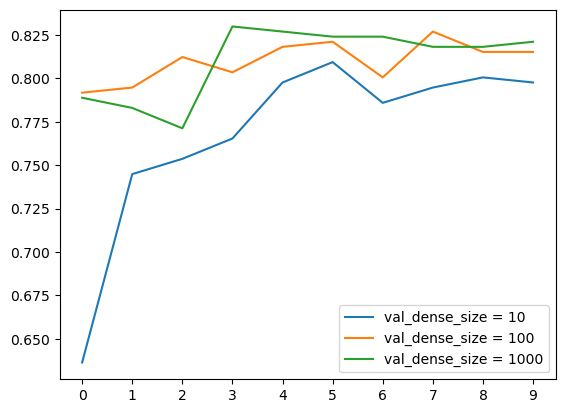

In [27]:
for size, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=f'val_dense_size = {size}')
plt.xticks(np.arange(10))
plt.legend()
plt.show()

## Regularization and dropout

- Regularizing by freezing a part of the network
- Adding dropout to our model
- Experimenting with different values

In [28]:
def make_model(learning_rate, size_inner=100, droprate=0.5):
    base_model = Xception(weights="imagenet", 
                      include_top=False, 
                      input_shape=(150, 150, 3))

    # freeze convolutional layers
    base_model.trainable=False

    ##############################################

    inputs = keras.Input(shape = (150, 150, 3))

    base = base_model(inputs, training = False)

    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)

    drop = keras.layers.Dropout(droprate)(inner)

    outputs = keras.layers.Dense(10)(drop)

    model = keras.Model(inputs, outputs)

    ##############################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [29]:
learning_rate = 0.001
size = 100

scores = {}

for droprate in [0.0, 0.2, 0.5, 0.8]:
    print(droprate)

    model = make_model(learning_rate=learning_rate, 
                       size_inner=size,
                       droprate=droprate)
    history = model.fit(train_ds, epochs=30, validation_data=val_ds)
    scores[droprate] = history.history

    print()
    print()

0.0
Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.6600 - loss: 0.9932 - val_accuracy: 0.7654 - val_loss: 0.6548
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.8230 - loss: 0.5240 - val_accuracy: 0.8094 - val_loss: 0.5692
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.8693 - loss: 0.3738 - val_accuracy: 0.8006 - val_loss: 0.5563
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.9175 - loss: 0.2643 - val_accuracy: 0.7683 - val_loss: 0.5788
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.9514 - loss: 0.1809 - val_accuracy: 0.8387 - val_loss: 0.5220
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.9729 - loss: 0.1237 - val_accuracy: 0.8152 - val_loss: 0.5324
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.9857 - loss: 0.0890 - val_accuracy: 0.8299 - val_loss: 0.5750
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.9892 - loss: 0.0684 - val_accuracy: 0.8065

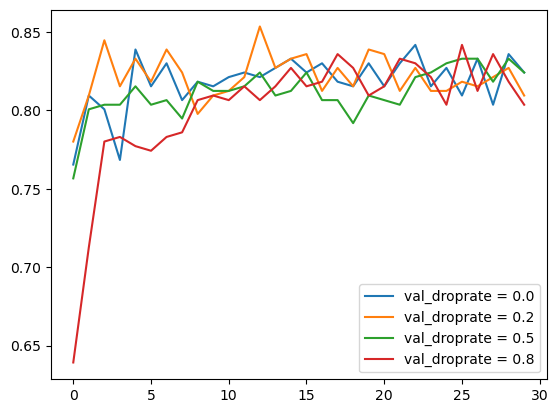

In [30]:
for size, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=f'val_droprate = {size}')
plt.legend()
plt.show()